In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]


(<Axes: >, <matplotlib.image.AxesImage at 0x181f67dfed0>)

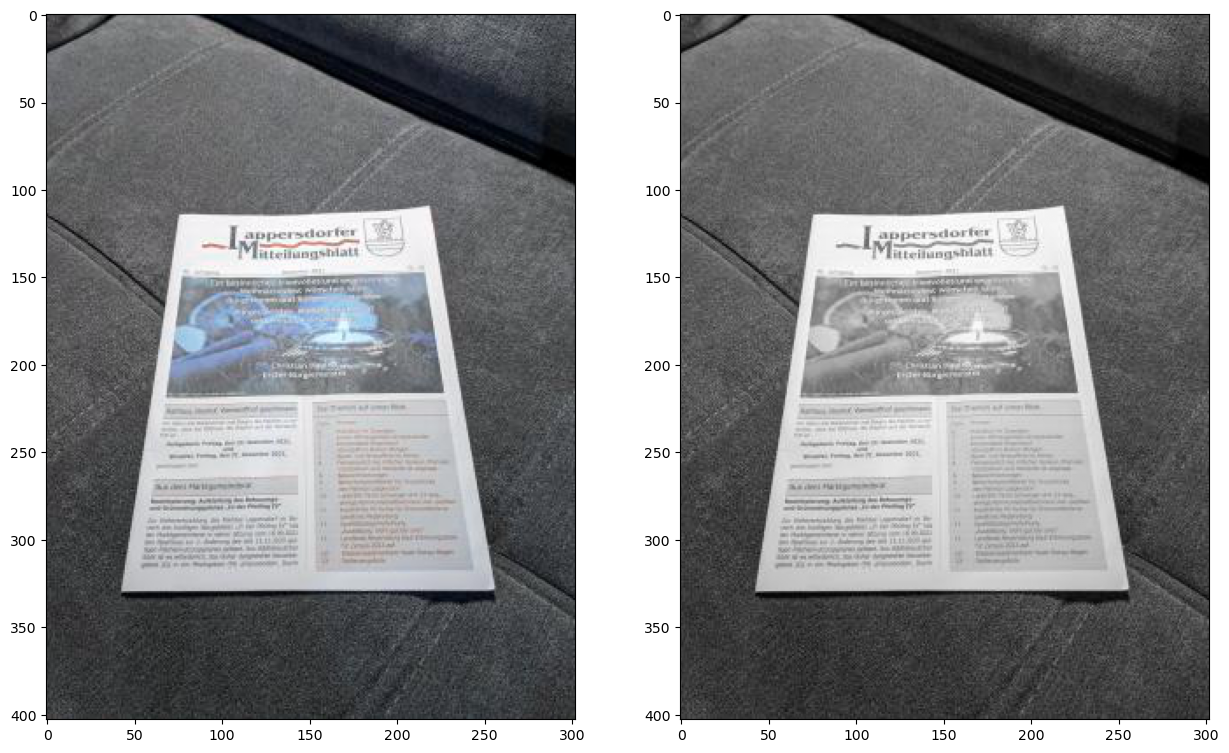

In [2]:
img = cv2.imread('Downloads/document.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

In [3]:
top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

(<Axes: >, <matplotlib.image.AxesImage at 0x181f8030f50>)

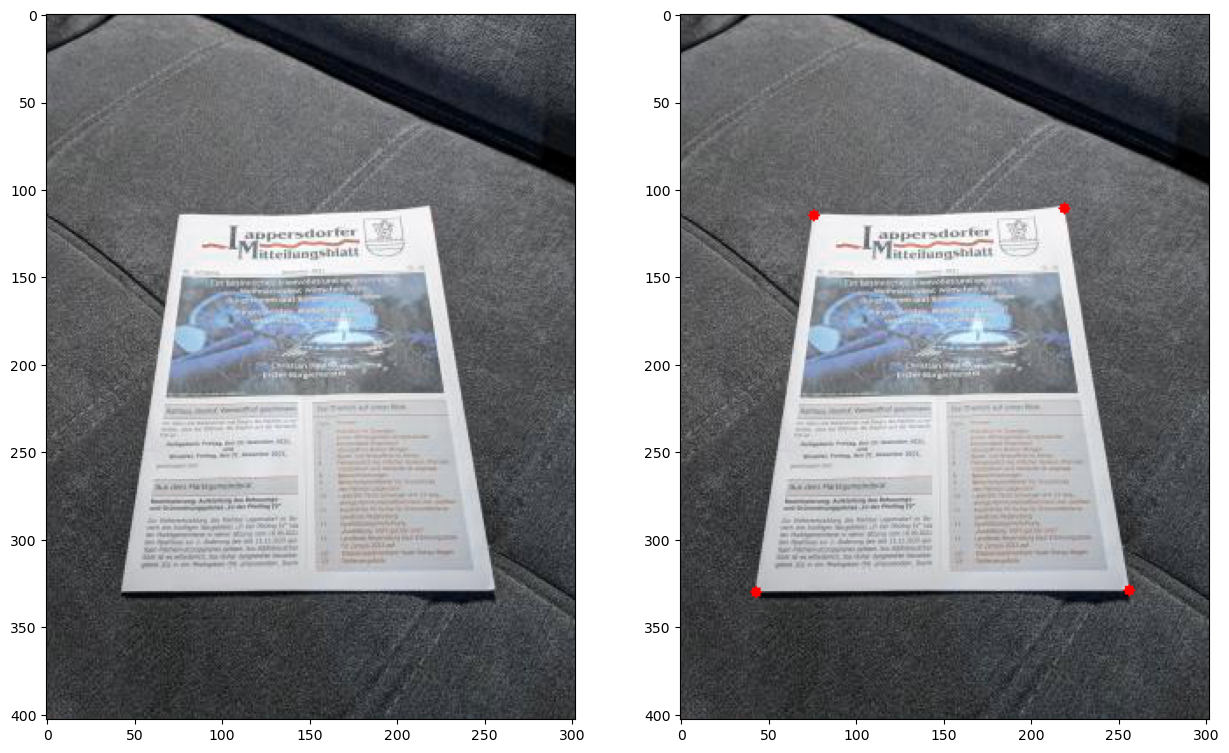

In [4]:
out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), -1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)


In [5]:
print(rows, cols)

403 302


In [6]:
src = np.array([top_left, top_right, bottom_left, bottom_right], dtype=np.float32)
dst = np.array([[0, 0],
                [cols - 1, 0],
                [0, rows - 1],
                [cols - 1, rows - 1]], dtype=np.float32)

(<Axes: >, <matplotlib.image.AxesImage at 0x181f7a60910>)

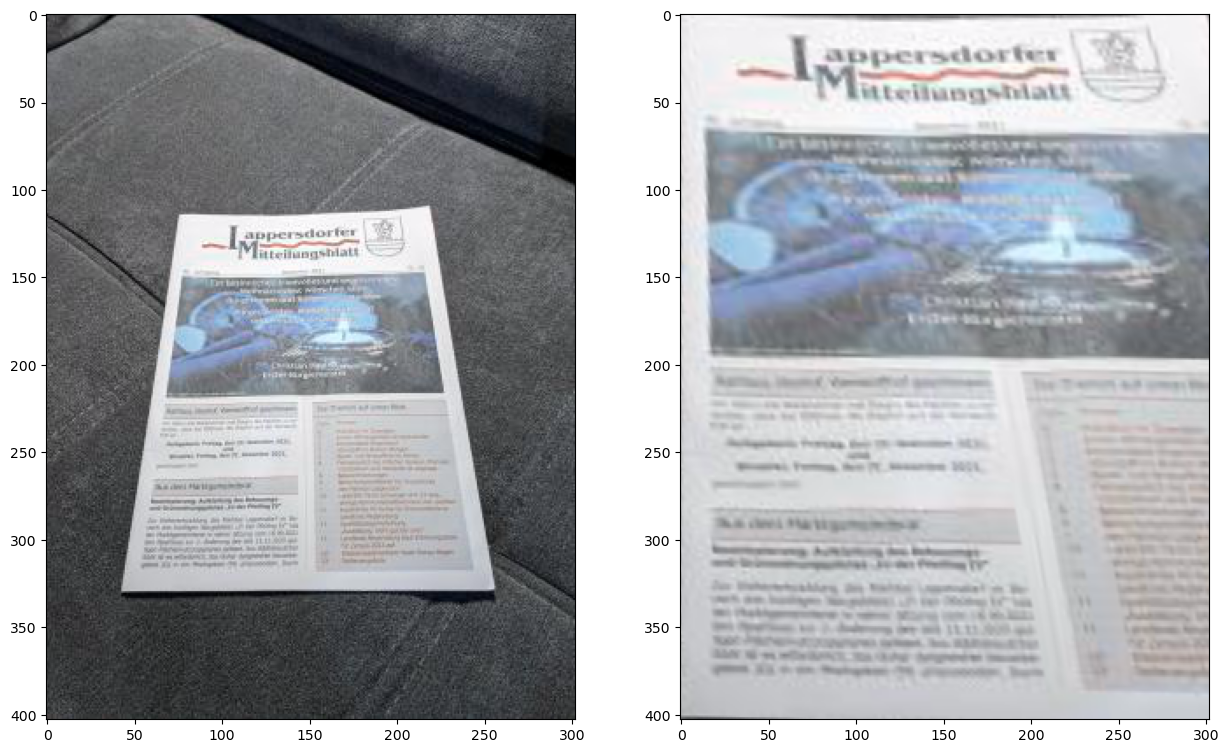

In [8]:
M = cv2.getAffineTransform(src[:3], dst[:3])
rectified = cv2.warpAffine(img, M, (cols, rows))
warped = rectified
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

(<Axes: >, <matplotlib.image.AxesImage at 0x181f83e4050>)

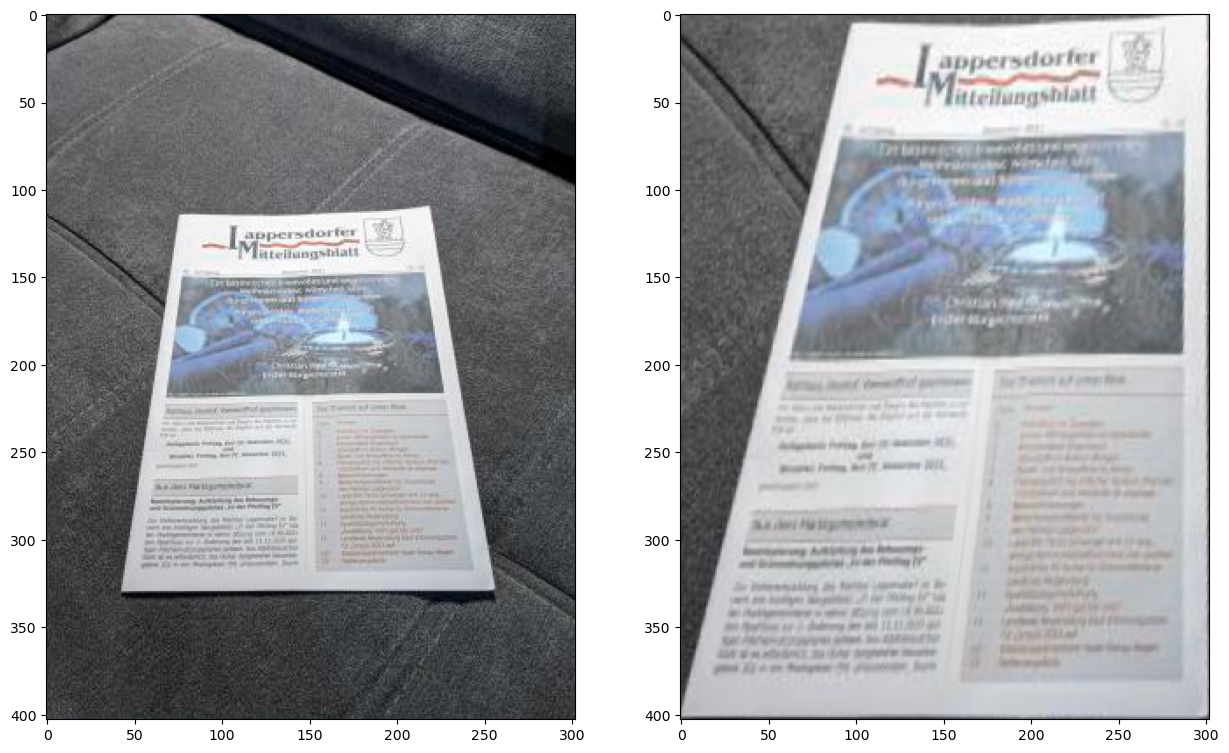

In [9]:
M = cv2.getAffineTransform(src[1:], dst[1:])
rectified = cv2.warpAffine(img, M, (cols, rows))
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

(<Axes: >, <matplotlib.image.AxesImage at 0x181f84af610>)

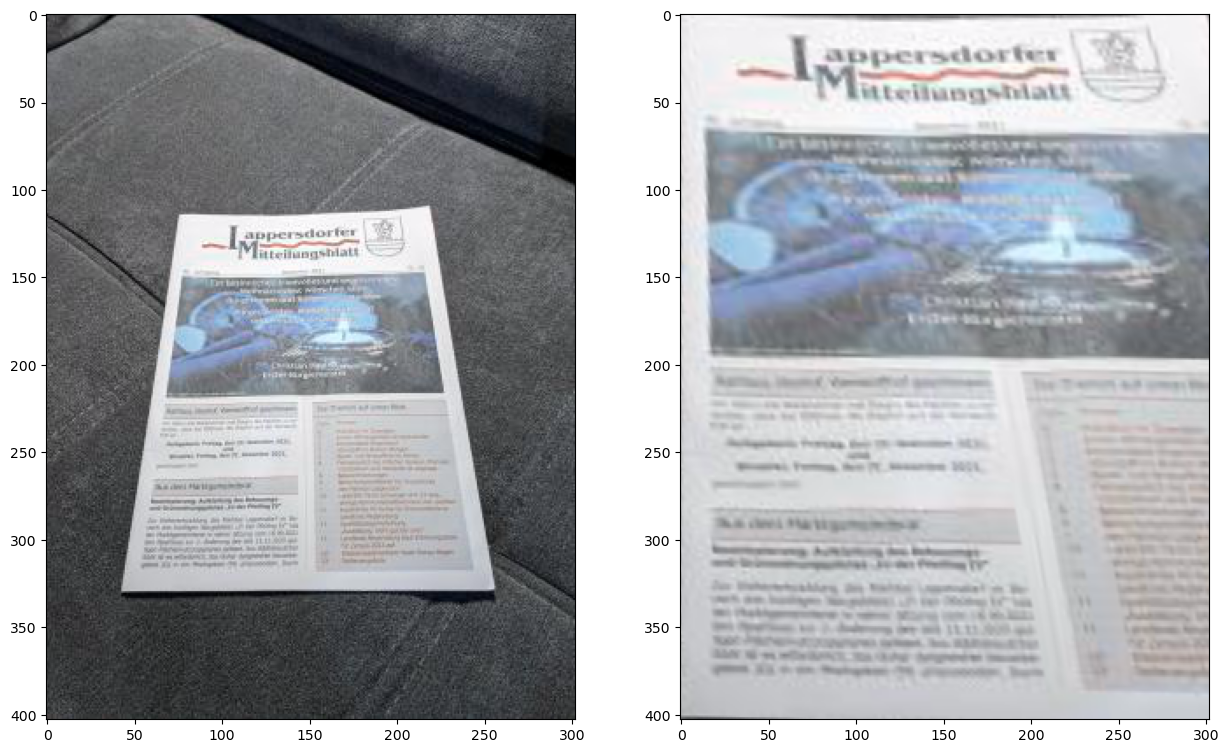

In [10]:
M, inliers = cv2.estimateAffine2D(src, dst)
rectified = cv2.warpAffine(img, M, (cols, rows))
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(warped)

In [11]:
M = cv2.getPerspectiveTransform(src, dst)
rectified = cv2.warpPerspective(img, M, (cols, rows))

(<Axes: >, <matplotlib.image.AxesImage at 0x181f8932ad0>)

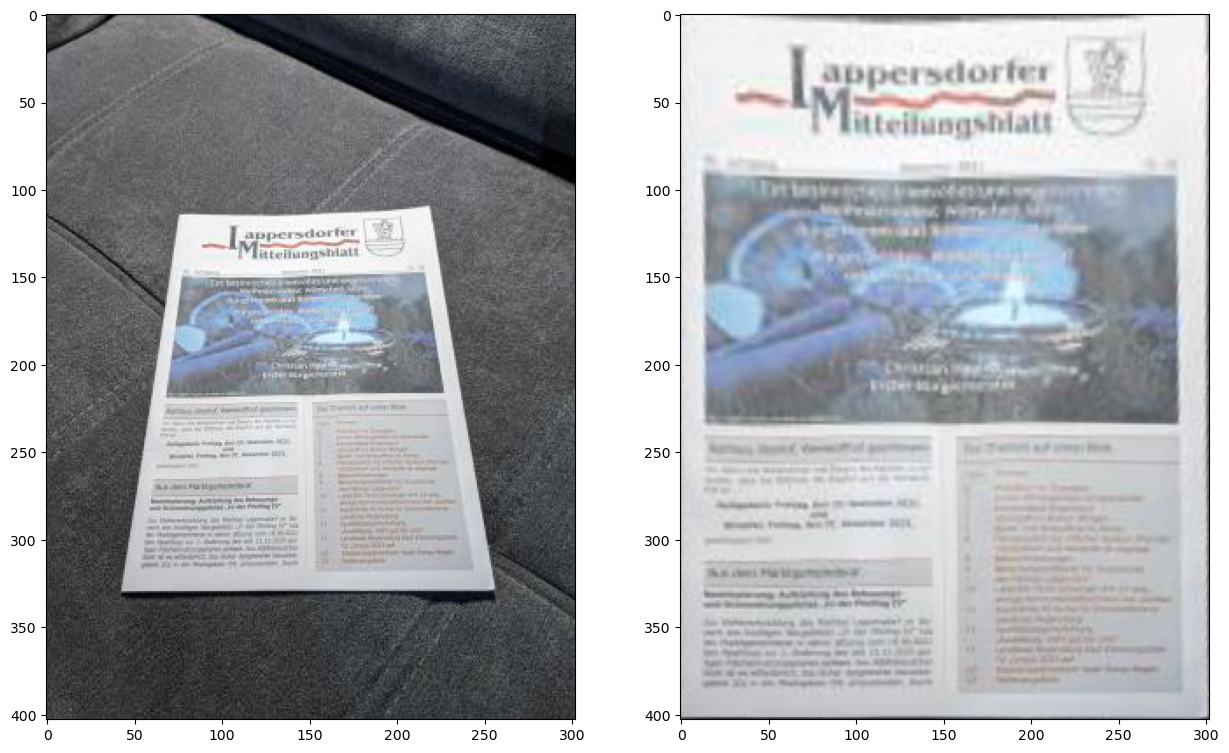

In [12]:
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

In [13]:
#1.Because affine transformation cannot describe perspective.
#2.These are good points that fit our model.
#3.Homography works well, but there are some drawbacks: the image is blurry and there are slight distortions. OCR will not work here.